# 1. Entendimiento del problema

Garment Industry es una compañia del sector textil con muchas actividades manuales. Su exito está en que las prendas son "hechas a mano", por lo que medir la productividad de sus empleados se vuelve esencial para mejorar las utilidades de la organización. Es por esto que la compañía quiere estimar los niveles de productividad de sus empleados para mejorar la operación y mantener los ingresos esperados, ademas identificar herramientas para mejorar el dia a dia de sus empleados

# 2. Enfoque analítico

Construir un modelo de regresión para predecir la productividad de cada empleado con un MAPE menor al 20% (Probabilidad superior al 80%)

# 3. Requerimientos de Datos
- Se requieren datos del trabajador en su puesto de trabajo particular.
- Se requieren mediciones del puesto de trabajo (tiempos, cantidad de prendas, momentos de ocio, cantidad de personas).
- Se requiere una medición inicial de la productividad.

# 4. Recolección de Datos
- date: Fecha de medición de la productividad.
- quarter: Trimestre de la medición.
- department: Area de trabajo en particular.
- day: Nombre del dia en el que se hizo la medición.
- team: Numero del equipo de trabajo.
- target_productivity: Productividad objetivo del area de trabajo.
- smv: Valor de tiempo estandar en minutos de la actividad.
- wip: Cantidad de trabajo en proceso (unidades).
- over_time: Tiempo en general de operación.
- incentive: Porcentaje de incentivos al área de trabajo.
- idle_time: Tiempo de parada.
- idle_men: Cantidad de trabajadores quieros en el tiempo de parada.
- no_of_style_change: Cantidad de cambios de estilo en la producción.
- no_of_workers: Cantidad total de trabajadores.
- actual_productivity: Productividad actual (**Y**).

In [2]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv('garments_worker_productivity.csv')
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

# 5. Entendimiento de los Datos
- Conocer nuestra variable y
- Identificar datos nulos
- Analisis univariado y multivariado

In [4]:
import matplotlib.pyplot as plt
import seaborn as sb

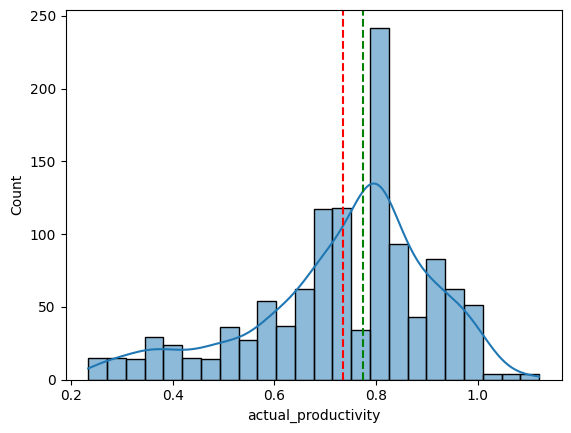

In [5]:
sb.histplot(data = data, x = 'actual_productivity', kde = True)
plt.axvline(x = data['actual_productivity'].mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data['actual_productivity'].median(), color = 'green', linestyle = 'dashed')
plt.show()

## Datos nulos

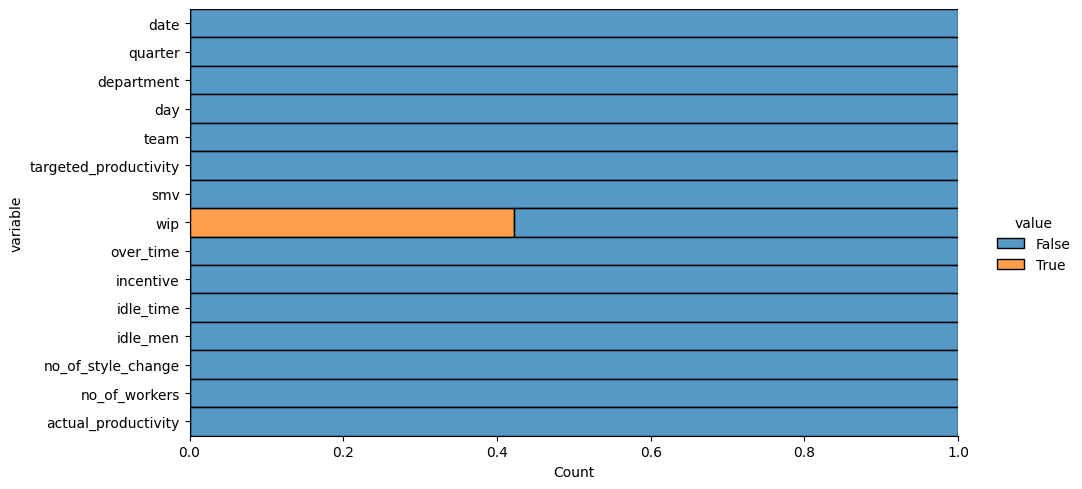

In [6]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

## Exploración univariada de los datos

### Variables numericas

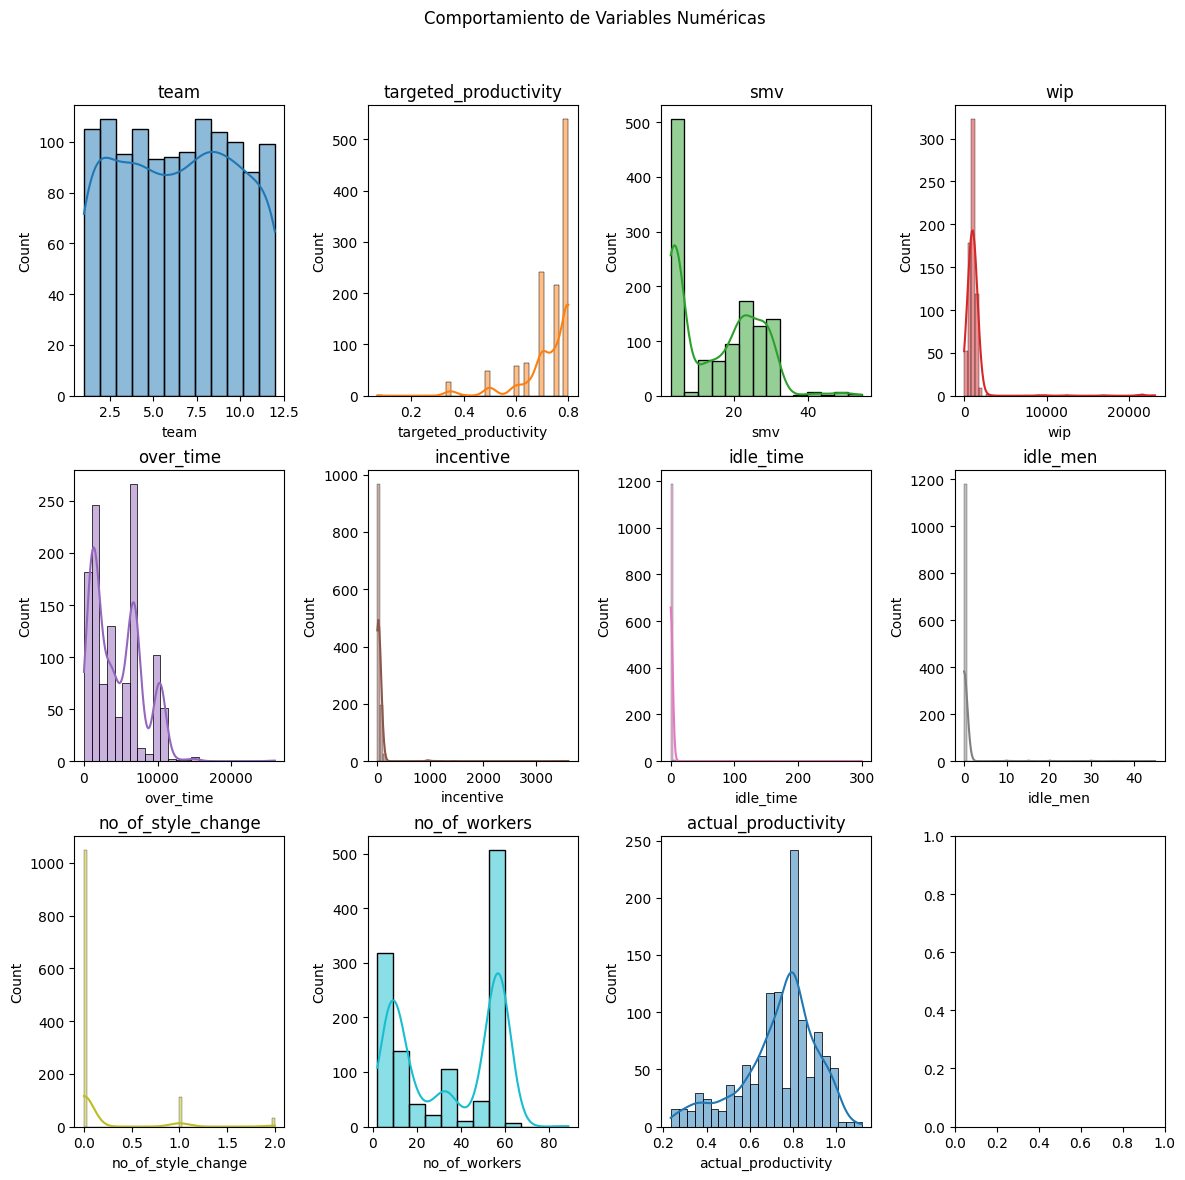

In [7]:
fig, ax = plt.subplots(3, 4, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns

for i, col in enumerate(num_col):
  sb.histplot(
    data = data,
    x = col, 
    kde = True,
    color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
    ax = ax[i]
  )
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

### Variables categoricas

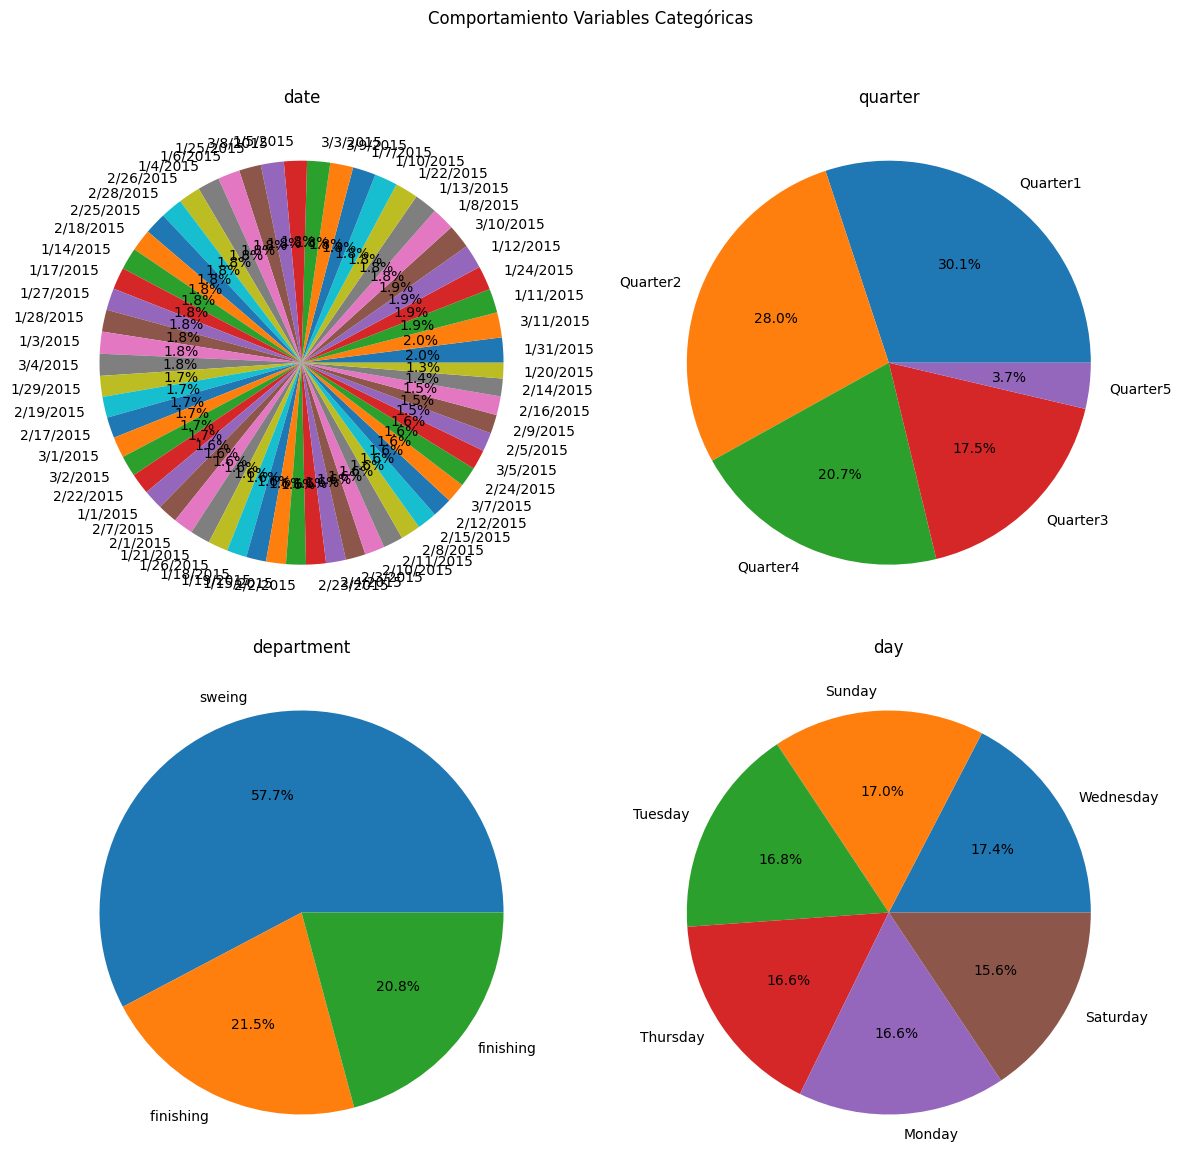

In [8]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns

for i, col in enumerate(cat_col):
  ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

## Correlacion

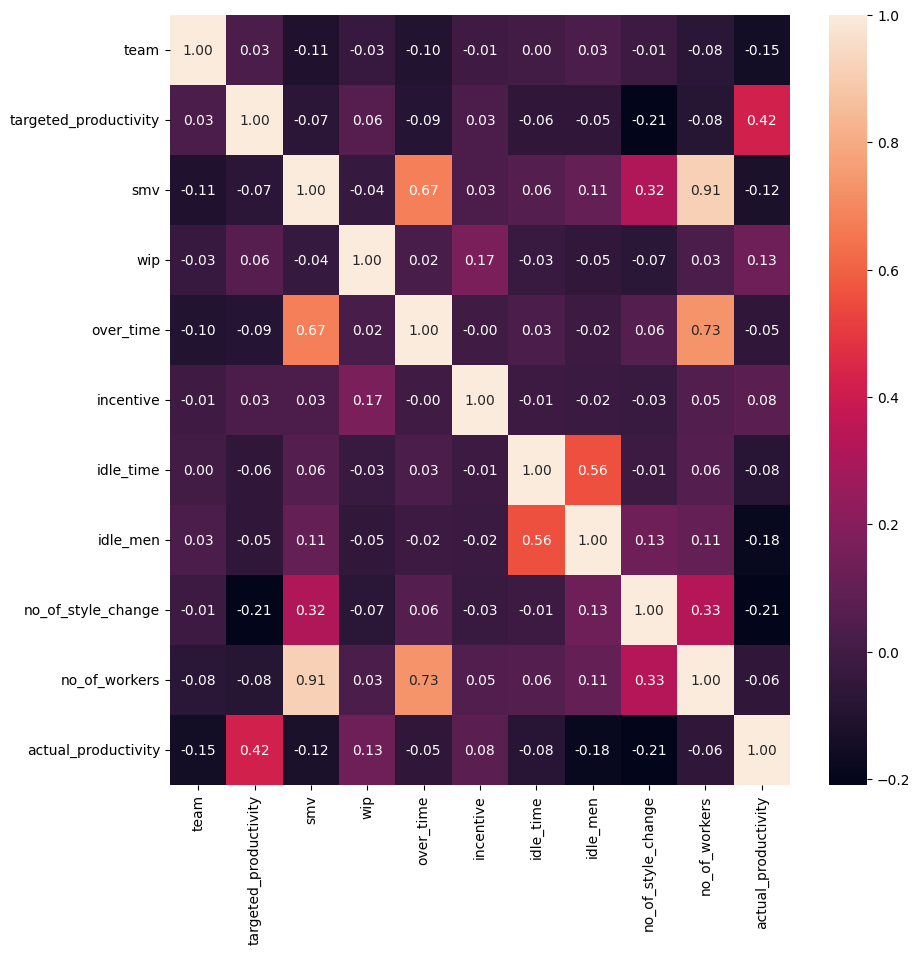

In [9]:
plt.figure(figsize=(10, 10))
sb.heatmap(data.corr(numeric_only = True), annot=True, fmt='.2f')
plt.show()

# 6. Preparación de los Datos

## Completar variables que cuentan con datos nulos (modelo recursivo)

In [10]:
import sklearn

categorical_cols = data.select_dtypes(include = ['object']).columns
categorical_transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_cols),
    remainder = 'passthrough'
)
categorical_transformer

,transformers,"[('ordinalencoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [11]:
data_transformed = pd.DataFrame(
  categorical_transformer.fit_transform(data),
  columns=categorical_transformer.get_feature_names_out(),
  index=data.index
).rename(
  columns=lambda x: x.removeprefix('ordinalencoder__')
).rename(
  columns=lambda x: x.removeprefix('remainder__')
)

data_transformed

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,0.0,0.0,2.0,3.0,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.940725
1,0.0,0.0,1.0,3.0,1.0,0.75,3.94,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.886500
2,0.0,0.0,2.0,3.0,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
3,0.0,0.0,2.0,3.0,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.800570
4,0.0,0.0,2.0,3.0,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,51.0,1.0,0.0,5.0,10.0,0.75,2.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.628333
1193,51.0,1.0,0.0,5.0,8.0,0.70,3.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.625625
1194,51.0,1.0,0.0,5.0,7.0,0.65,3.90,NaN,960.0,0.0,0.0,0.0,0.0,8.0,0.625625
1195,51.0,1.0,0.0,5.0,9.0,0.75,2.90,NaN,1800.0,0.0,0.0,0.0,0.0,15.0,0.505889


In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_iterative_imputer

recursive_imputer = sklearn.impute.IterativeImputer(estimator = DecisionTreeRegressor(),
                                                    initial_strategy = 'mean',
                                                    max_iter = 10)
data_recursive_df = pd.DataFrame(recursive_imputer.fit_transform(data_transformed).round(2),
                                 columns = data_transformed.columns,
                                 index = data_transformed.index)
data_recursive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   float64
 1   quarter                1197 non-null   float64
 2   department             1197 non-null   float64
 3   day                    1197 non-null   float64
 4   team                   1197 non-null   float64
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   float64
 9   incentive              1197 non-null   float64
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   float64
 12  no_of_style_change     1197 non-null   float64
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [13]:
data_imputed = data_recursive_df.copy()
data_imputed[categorical_cols] = (categorical_transformer.named_transformers_.ordinalencoder.inverse_transform(X = data_recursive_df[categorical_cols]))
data_imputed

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8.0,0.80,26.16,1108.0,7080.0,98.0,0.0,0.0,0.0,59.0,0.94
1,1/1/2015,Quarter1,finishing,Thursday,1.0,0.75,3.94,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.89
2,1/1/2015,Quarter1,sweing,Thursday,11.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
3,1/1/2015,Quarter1,sweing,Thursday,12.0,0.80,11.41,968.0,3660.0,50.0,0.0,0.0,0.0,30.5,0.80
4,1/1/2015,Quarter1,sweing,Thursday,6.0,0.80,25.90,1170.0,1920.0,50.0,0.0,0.0,0.0,56.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10.0,0.75,2.90,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1193,3/11/2015,Quarter2,finishing,Wednesday,8.0,0.70,3.90,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1194,3/11/2015,Quarter2,finishing,Wednesday,7.0,0.65,3.90,813.0,960.0,0.0,0.0,0.0,0.0,8.0,0.63
1195,3/11/2015,Quarter2,finishing,Wednesday,9.0,0.75,2.90,813.0,1800.0,0.0,0.0,0.0,0.0,15.0,0.51


In [14]:
data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   float64
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   float64
 9   incentive              1197 non-null   float64
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   float64
 12  no_of_style_change     1197 non-null   float64
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [15]:
data_imputed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.00,3.00,6.00,9.00,12.00
targeted_productivity,1197.0,0.729632,0.097891,0.07,0.70,0.75,0.80,0.80
smv,1197.0,15.062172,10.943219,2.90,3.94,15.26,24.26,54.56
wip,1197.0,1170.288221,2197.652682,7.00,629.00,935.00,1216.00,23122.00
over_time,1197.0,4567.460317,3348.823563,0.00,1440.00,3960.00,6960.00,25920.00
incentive,1197.0,38.210526,160.182643,0.00,0.00,0.00,50.00,3600.00
idle_time,1197.0,0.730159,12.709757,0.00,0.00,0.00,0.00,300.00
idle_men,1197.0,0.369256,3.268987,0.00,0.00,0.00,0.00,45.00
no_of_style_change,1197.0,0.150376,0.427848,0.00,0.00,0.00,0.00,2.00
no_of_workers,1197.0,34.609858,22.197687,2.00,9.00,34.00,57.00,89.00


## Eliminar variables que no son significativas

In [16]:
data_mod = data_imputed.drop(columns = ['team', 'no_of_style_change', 'no_of_workers', 'incentive', 'idle_men'], axis = 1)

## Ajustar variable department

In [17]:
data_mod['department'].replace({ 'finishing ': 'finishing' }, inplace = True)

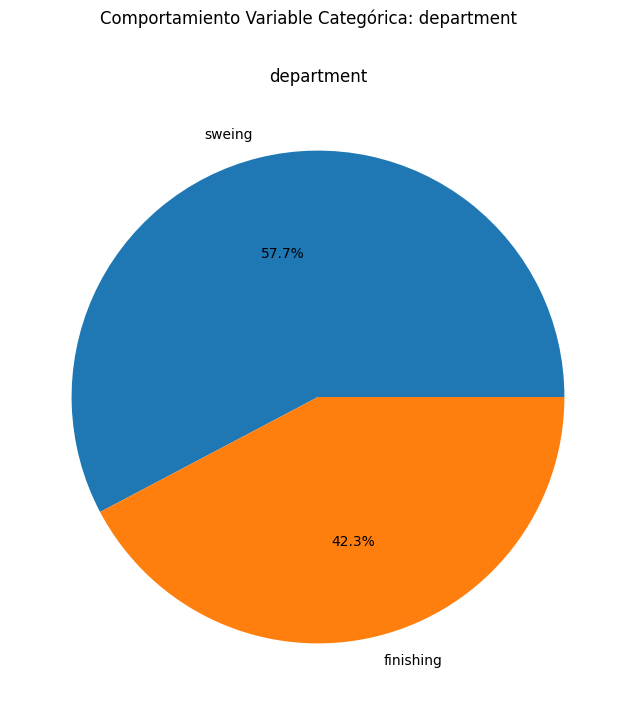

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
  x=data_mod['department'].value_counts(),
  labels=data_mod['department'].value_counts().index,
  autopct='%0.1f%%'
)
ax.set_title('department')
fig.suptitle("Comportamiento Variable Categórica: department")
plt.show()


## Manejo variables tipo fecha

In [19]:
data_mod['date'] = pd.to_datetime(data_mod['date'], format='%m/%d/%Y')

data_mod['num_day'] = [i.day for i in data_mod.date]
data_mod['num_month'] = [i.month for i in data_mod.date]

data_mod.drop(columns = ['date'], axis = 1, inplace = True)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   object 
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   targeted_productivity  1197 non-null   float64
 4   smv                    1197 non-null   float64
 5   wip                    1197 non-null   float64
 6   over_time              1197 non-null   float64
 7   idle_time              1197 non-null   float64
 8   actual_productivity    1197 non-null   float64
 9   num_day                1197 non-null   int64  
 10  num_month              1197 non-null   int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 103.0+ KB


## Pipeline

In [20]:
# Transformaciones de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline

In [21]:
num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_col = data_mod.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder())])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', num_transformer, num_col),
    ('cat', cat_transformer, cat_col)
  ],
  remainder='passthrough'
)
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [22]:
data_pre = preprocessor.fit_transform(data_mod)

cod_cat = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])

data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro

,targeted_productivity,smv,wip,over_time,idle_time,actual_productivity,num_day,num_month,quarter_Quarter1,quarter_Quarter2,...,quarter_Quarter4,quarter_Quarter5,department_finishing,department_sweing,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,1.000000,0.450252,0.047631,0.273148,0.0,0.797753,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.931507,0.020132,0.034869,0.037037,0.0,0.741573,0.000000,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.000000,0.164731,0.041575,0.141204,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.000000,0.164731,0.041575,0.141204,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.000000,0.445219,0.050314,0.074074,0.0,0.640449,0.000000,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,0.931507,0.000000,0.034869,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1193,0.863014,0.019357,0.034869,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1194,0.794521,0.019357,0.034869,0.037037,0.0,0.449438,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1195,0.931507,0.000000,0.034869,0.069444,0.0,0.314607,0.333333,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Separacion variables X y Y

In [23]:
X = data_pro.drop(columns = ['actual_productivity'], axis = 1)
y = data_pro['actual_productivity']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=123)
print(f'El tamaño del conjunto de prueba es: {X_test.shape} {y_test.shape}')
print(f'El tamaño del conjunto de entrenamiento es: {X_train.shape} {y_train.shape}')

El tamaño del conjunto de prueba es: (838, 20) (838,)
El tamaño del conjunto de entrenamiento es: (359, 20) (359,)


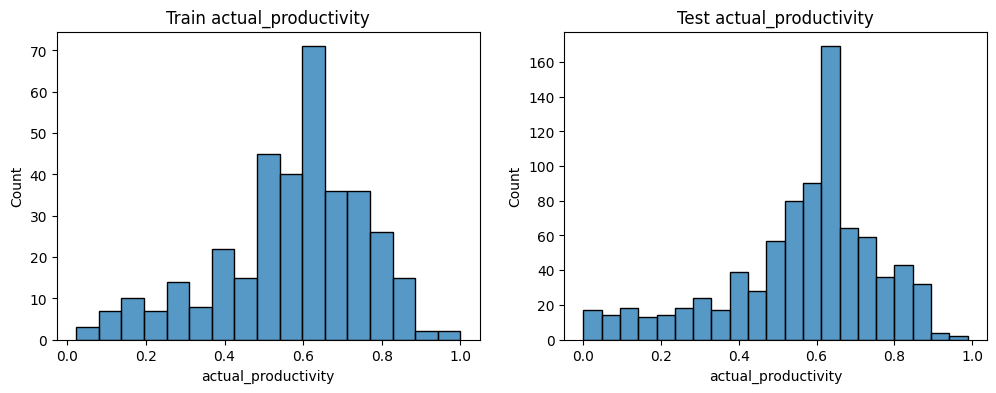

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sb.histplot(y_train, ax=ax[0])
ax[0].set_title('Train actual_productivity')

sb.histplot(y_test, ax=ax[1])
ax[1].set_title('Test actual_productivity')

plt.show()

# 7. Modelado

- Regresion lineal
- K vecinos mas cercanos
- Maquina de soporte vectorial
- Arboles de decision
- Random Forest
- Gradient Boosting
- Percepcion Multicapa

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Regresion lineal

In [27]:
modelo_1 = LinearRegression()
modelo_1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
modelo_1.coef_

array([ 0.47285345, -0.08004113,  0.2026374 ,  0.1135591 , -0.17408336,
        0.28941372, -0.01474809,  0.12992213,  0.07184883, -0.02778574,
       -0.12610403, -0.04788119,  0.01467585, -0.01467585, -0.01246199,
        0.00053684,  0.00479614, -0.01312179,  0.0290238 , -0.00877301])

In [ ]:
modelo_1.intercept_

np.float64(0.0035611839616690455)

## K Vecinos más cercanos

In [55]:
modelo_2 = KNeighborsRegressor()

param_grid = {
  'n_neighbors': [2, 5, 9, 15, 25, 40, 35],
  'p': [1, 2],
}

reg_2 = GridSearchCV(estimator=modelo_2, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_2.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_2.cv_results_['params']),
    pd.DataFrame(reg_2.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,n_neighbors,p,MAPE
5,9,2,-0.520174
7,15,2,-0.520290
4,9,1,-0.520543
6,15,1,-0.521586
8,25,1,-0.532371
9,25,2,-0.534503
10,40,1,-0.539071
12,35,1,-0.539118
11,40,2,-0.540049
13,35,2,-0.540920


In [78]:
modelo_2_final = reg_2.best_estimator_
modelo_2_final

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Maquina de soporte Vectorial

In [75]:
modelo_3 = SVR()

param_grid = {
  'C': [0, 0.01, 1, 10, 100],
  'kernel': ['linear', 'poly', 'rbf'],
  'degree': [2, 3]
}

reg_3 = GridSearchCV(estimator=modelo_3, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_3.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_3.cv_results_['params']),
    pd.DataFrame(reg_3.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,C,degree,kernel,MAPE
25,100.00,2,poly,-0.479308
19,10.00,2,poly,-0.485222
29,100.00,3,rbf,-0.497448
26,100.00,2,rbf,-0.497448
22,10.00,3,poly,-0.502456
16,1.00,3,poly,-0.504057
13,1.00,2,poly,-0.506248
12,1.00,2,linear,-0.506956
15,1.00,3,linear,-0.506956
27,100.00,3,linear,-0.507839


In [77]:
modelo_3_final = reg_3.best_estimator_
modelo_3_final

,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Arbol de Regresion

In [85]:
modelo_4 = DecisionTreeRegressor(random_state=123)

param_grid = {
  'criterion': ['friedman_mse', 'poisson', 'squared_error', 'absolute_error'],
  'max_depth': [None, 5, 6, 3, 4, 10, 100],
  'min_samples_split': [2, 3],
  'max_leaf_nodes': [None, 2, 3, 4]
}

reg_4 = GridSearchCV(estimator=modelo_4, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_percentage_error')
reg_4.fit(X_train, y_train)

validation = pd.concat(
  [
    pd.DataFrame(reg_4.cv_results_['params']),
    pd.DataFrame(reg_4.cv_results_['mean_test_score'], columns=['MAPE'])
  ],
  axis=1
)
validation.sort_values('MAPE', ascending=False)

# Al usar MAPE, el mejor es el valor más cercano a 0, pero como sklearn usa el negativo, el mejor es el más cercano a 0 por la izquierda (el menos negativo)

,criterion,max_depth,max_leaf_nodes,min_samples_split,MAPE
177,absolute_error,5.0,NaN,3,-0.405748
185,absolute_error,6.0,NaN,3,-0.409624
176,absolute_error,5.0,NaN,2,-0.409908
201,absolute_error,4.0,NaN,3,-0.411485
200,absolute_error,4.0,NaN,2,-0.411485
...,...,...,...,...,...
194,absolute_error,3.0,2.0,2,-0.498063
210,absolute_error,10.0,2.0,2,-0.498063
211,absolute_error,10.0,2.0,3,-0.498063
219,absolute_error,100.0,2.0,3,-0.498063


In [84]:
modelo_4_final = reg_4.best_estimator_
modelo_4_final

,criterion,'absolute_error'
,splitter,'best'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


# 8. Validacion

- Ajuste cuadrfatico
- Raiz del error cuadratico medio
- Error medio absoluto
- Porcentaje del error medio absoluto

## Funciones de validacion

In [79]:
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

def predecir_y_desescalar(modelo, X_train, X_test, y_train, y_test, y_total):
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)
    y_min, y_max = np.min(y_total), np.max(y_total)
    pred_train_des = pred_train * (y_max - y_min) + y_min
    pred_test_des = pred_test * (y_max - y_min) + y_min
    y_train_des = y_train * (y_max - y_min) + y_min
    y_test_des = y_test * (y_max - y_min) + y_min
    return pred_train_des, pred_test_des, y_train_des, y_test_des

def mostrar_metricas(y_train_des, pred_train_des, y_test_des, pred_test_des, nombre_modelo="Modelo"):
    # Entrenamiento
    r2_train = r2_score(y_train_des, pred_train_des)
    rmse_train = root_mean_squared_error(y_train_des, pred_train_des)
    mae_train = mean_absolute_error(y_train_des, pred_train_des)
    mape_train = mean_absolute_percentage_error(y_train_des, pred_train_des) * 100

    print(f"Las métricas de desempeño en entrenamiento para {nombre_modelo} son:")
    print(f"R2: {r2_train}")
    print(f"RMSE: {rmse_train}")
    print(f"MAE: {mae_train}")
    print(f"MAPE: {mape_train / 100}")

    sb.histplot(data=y_train_des, label='Datos de entrenamiento')
    sb.histplot(pred_train_des, label='Predicciones de entrenamiento')
    plt.legend()
    plt.show()

    # Test
    r2_test = r2_score(y_test_des, pred_test_des)
    rmse_test = root_mean_squared_error(y_test_des, pred_test_des)
    mae_test = mean_absolute_error(y_test_des, pred_test_des)
    mape_test = mean_absolute_percentage_error(y_test_des, pred_test_des) * 100

    print(f"Las métricas de desempeño en test para {nombre_modelo} son:")
    print(f"R2: {r2_test}")
    print(f"RMSE: {rmse_test}")
    print(f"MAE: {mae_test}")
    print(f"MAPE: {mape_test / 100}")

    sb.histplot(data=y_test_des, label='Datos de test')
    sb.histplot(pred_test_des, label='Predicciones de test')
    plt.legend()
    plt.show()

## Regresion lineal

Las métricas de desempeño en entrenamiento para Regresión Lineal son:
R2: 0.19388342438605366
RMSE: 0.1660587201666229
MAE: 0.12003824948707924
MAPE: 0.4612604732299275


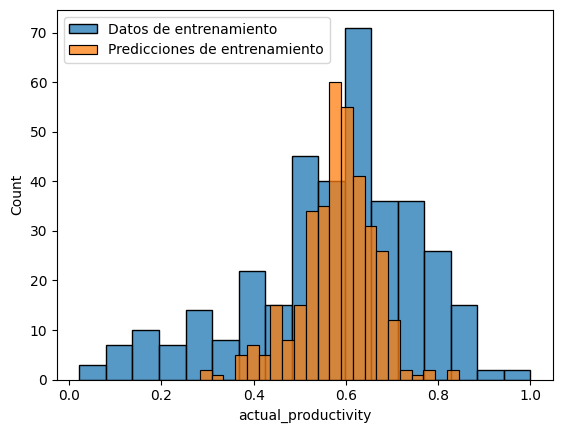

Las métricas de desempeño en test para Regresión Lineal son:
R2: 0.19755826902903773
RMSE: 0.17927044794160046
MAE: 0.12879668319168983
MAPE: 2758273027217.4204


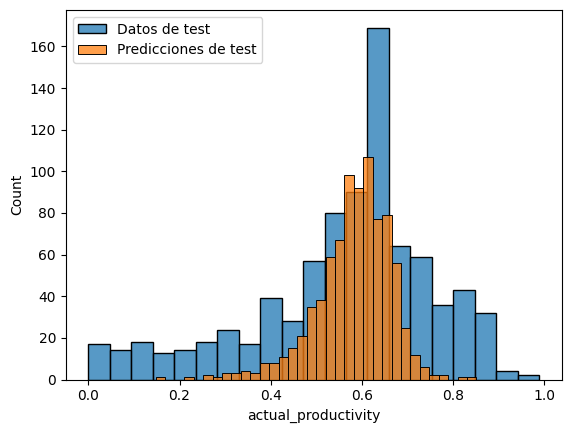

In [80]:
pred_train_1, pred_test_1, y_train_des, y_test_des = predecir_y_desescalar(modelo_1, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_1, y_test_des, pred_test_1, nombre_modelo="Regresión Lineal")

## K Vecinos mas cercanos

Las métricas de desempeño en entrenamiento para KNN son:
R2: 0.2145019814430702
RMSE: 0.16392126907374227
MAE: 0.1259602377251277
MAPE: 0.478694922944928


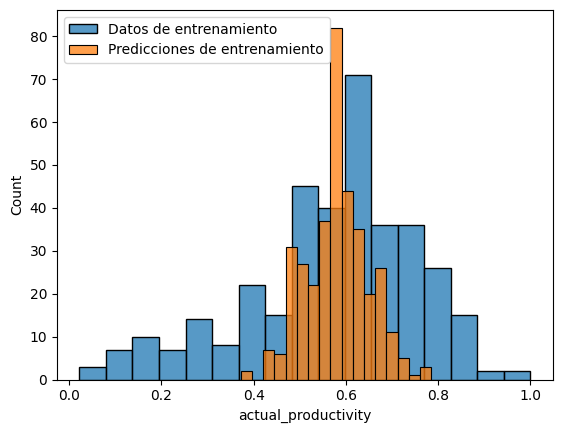

Las métricas de desempeño en test para KNN son:
R2: 0.0014976288033693441
RMSE: 0.1999753662624876
MAE: 0.14955053200206184
MAPE: 2764269970527.919


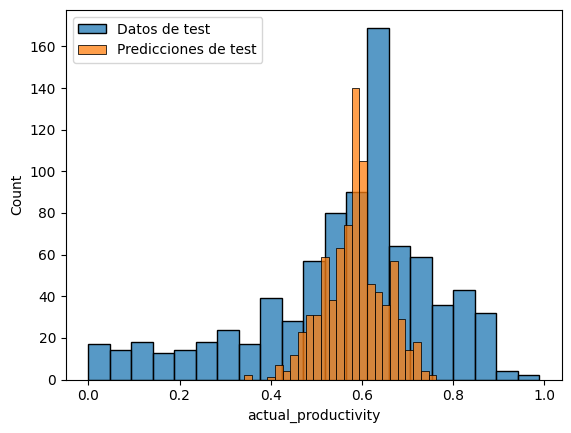

In [81]:
pred_train_2, pred_test_2, y_train_des, y_test_des = predecir_y_desescalar(modelo_2_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_2, y_test_des, pred_test_2, nombre_modelo="KNN")

# Maquina de Soporte Vectorial

Las métricas de desempeño en entrenamiento para MSV son:
R2: 0.5112619592531212
RMSE: 0.1293006870425596
MAE: 0.09601034393646549
MAPE: 0.35291447950671734


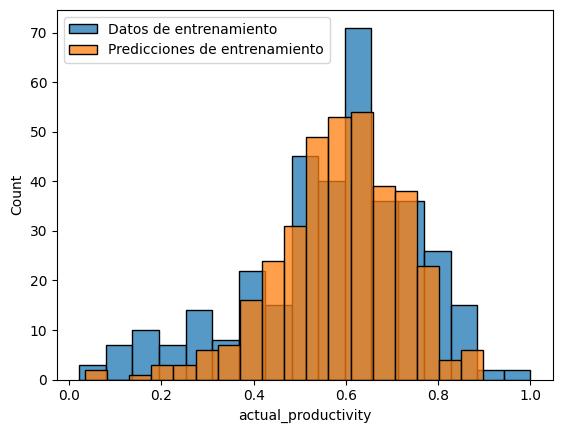

Las métricas de desempeño en test para MSV son:
R2: -0.018309771380025097
RMSE: 0.2019490926232598
MAE: 0.14894996441976316
MAPE: 902559766054.7372


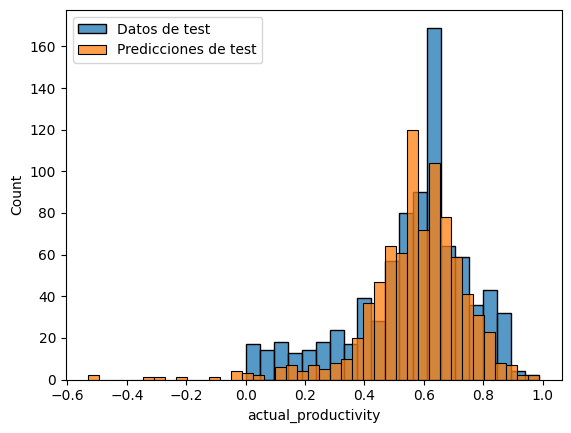

In [86]:
pred_train_3, pred_test_3, y_train_des, y_test_des = predecir_y_desescalar(modelo_3_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_3, y_test_des, pred_test_3, nombre_modelo="MSV")

## Arbol de Regresion

Las métricas de desempeño en entrenamiento para Arbol Regresion son:
R2: 0.5115226170466757
RMSE: 0.1292662025908705
MAE: 0.0715157585052111
MAPE: 0.32589930670038814


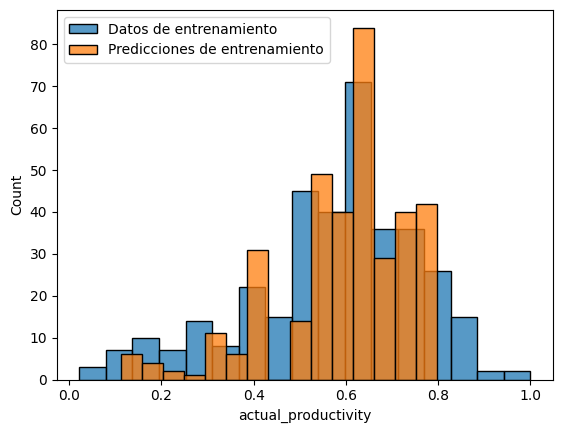

Las métricas de desempeño en test para Arbol Regresion son:
R2: 0.18281693535372168
RMSE: 0.18090960669898748
MAE: 0.10822316376605612
MAPE: 2838073294983.607


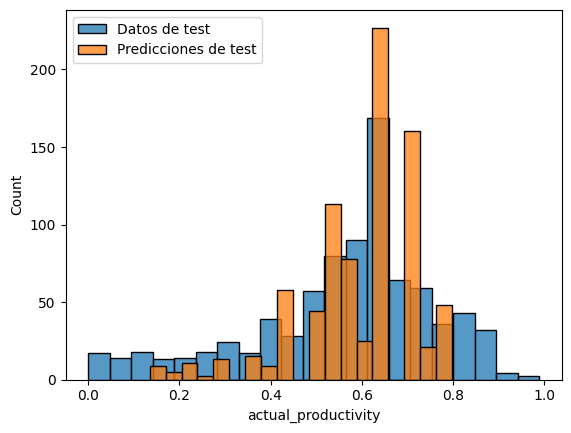

In [87]:
pred_train_4, pred_test_4, y_train_des, y_test_des = predecir_y_desescalar(modelo_4_final, X_train, X_test, y_train, y_test, y)
mostrar_metricas(y_train_des, pred_train_4, y_test_des, pred_test_4, nombre_modelo="Arbol Regresion")